# House Price Prediction — Regression & Classification

This notebook walks through an end-to-end machine learning workflow on the **House Prices** dataset (Indian real-estate listings):

1. Data Loading & Inspection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Modeling — Linear Regression (predict price)
6. Modeling — Classification (Logistic Regression, predict price category)
7. Evaluation & Conclusions


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', 50)


## 1. Data Loading & Inspection

In [2]:
df = pd.read_csv('house_prices.csv')
print("Shape:", df.shape)
df.head()


Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.isna().mean().sort_values(ascending=False).to_frame('missing_fraction')


,missing_fraction
Plot Area,1.000000
Dimensions,1.000000
Society,0.584853
Super Area,0.574225
Car Parking,0.551146
overlooking,0.434254
Carpet Area,0.430185
facing,0.374514
Ownership,0.349366
Balcony,0.260944


## 2. Data Cleaning

The raw columns are messy strings (e.g. `"1.40 Cr "`, `"500 sqft"`, `"10 out of 11"`). We parse them into clean numeric columns.

In [5]:
def parse_amount(x):
    """Convert '42 Lac', '1.40 Cr' style strings into rupee values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    m = re.match(r'([\d.]+)\s*(Lac|Cr)?', x)
    if not m or m.group(1) == '':
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    if unit == 'Cr':
        val *= 1e7
    elif unit == 'Lac':
        val *= 1e5
    return val

def parse_area(x):
    """Extract numeric sqft from strings like '500 sqft'."""
    if pd.isna(x):
        return np.nan
    m = re.match(r'([\d,.]+)', str(x).strip())
    if not m:
        return np.nan
    return float(m.group(1).replace(',', ''))

def parse_floor(x):
    """Split '10 out of 11' into (floor_number, total_floors)."""
    if pd.isna(x):
        return np.nan, np.nan
    parts = str(x).split(' out of ')
    if len(parts) != 2:
        return np.nan, np.nan
    f_raw = parts[0].strip()
    f = 0 if f_raw == 'Ground' else re.sub(r'\D', '', f_raw)
    t = re.sub(r'\D', '', parts[1])
    f_val = float(f) if (f == 0 or f) else np.nan
    t_val = float(t) if t else np.nan
    return f_val, t_val

def parse_bhk(title):
    """Extract number of bedrooms (BHK) from the listing title."""
    m = re.search(r'(\d+)\s*BHK', str(title))
    return float(m.group(1)) if m else np.nan


In [6]:
df_c = df.copy()

# Price target (in rupees)
df_c['Price_Rs'] = df_c['Amount(in rupees)'].apply(parse_amount)

# Area: prefer Carpet Area, fall back to Super Area
df_c['Carpet_Area_sqft'] = df_c['Carpet Area'].apply(parse_area)
df_c['Super_Area_sqft'] = df_c['Super Area'].apply(parse_area)
df_c['Area_sqft'] = df_c['Carpet_Area_sqft'].fillna(df_c['Super_Area_sqft'])

# Floor info
floor_parsed = df_c['Floor'].apply(parse_floor)
df_c['Floor_num'] = floor_parsed.apply(lambda t: t[0])
df_c['Total_floors'] = floor_parsed.apply(lambda t: t[1])

# Bathrooms / balconies
df_c['Bathroom_num'] = pd.to_numeric(df_c['Bathroom'].astype(str).str.replace('> 10', '11'), errors='coerce')
df_c['Balcony_num'] = pd.to_numeric(df_c['Balcony'].astype(str).str.replace('> 10', '11'), errors='coerce')

# Bedrooms (BHK) parsed from title
df_c['BHK'] = df_c['Title'].apply(parse_bhk)

df_c[['Price_Rs', 'Area_sqft', 'Floor_num', 'Total_floors', 'Bathroom_num', 'Balcony_num', 'BHK']].describe()


,Price_Rs,Area_sqft,Floor_num,Total_floors,Bathroom_num,Balcony_num,BHK
count,1.778470e+05,186704.000000,180044.000000,180405.000000,186703.000000,138596.000000,186610.000000
mean,1.198134e+07,1252.464184,4.454028,8.774064,2.428247,2.001782,2.569691
std,3.943827e+07,2659.659913,4.661898,7.612077,0.871107,0.958087,0.786524
min,1.000000e+05,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,4.840000e+06,800.000000,2.000000,4.000000,2.000000,1.000000,2.000000
50%,7.800000e+06,1140.000000,3.000000,5.000000,2.000000,2.000000,3.000000
75%,1.450000e+07,1551.000000,6.000000,11.000000,3.000000,3.000000,3.000000
max,1.400300e+10,709222.000000,200.000000,200.000000,11.000000,11.000000,10.000000


In [7]:
# Drop rows without a target price, or with non-sensical area/price
df_c = df_c[df_c['Price_Rs'].notna()]
df_c = df_c[(df_c['Area_sqft'].isna()) | (df_c['Area_sqft'] > 50)]   # drop unrealistic tiny areas
df_c = df_c[df_c['Price_Rs'].between(1e5, 1e9)]                      # drop extreme price outliers (>10 lac, <100cr)

# Keep only relevant columns for modeling
cols_keep = ['Price_Rs', 'Area_sqft', 'BHK', 'Bathroom_num', 'Balcony_num',
             'Floor_num', 'Total_floors', 'location', 'Transaction',
             'Furnishing', 'Status', 'Ownership', 'facing']
df_c = df_c[cols_keep]

print("Shape after cleaning:", df_c.shape)
df_c.isna().mean().sort_values(ascending=False).to_frame('missing_fraction')


Shape after cleaning: (174764, 13)


,missing_fraction
facing,0.368514
Ownership,0.346845
Balcony_num,0.267263
Floor_num,0.041885
Total_floors,0.039991
Furnishing,0.011782
Bathroom_num,0.004314
Status,0.003393
BHK,0.001757
Area_sqft,0.000515


In [8]:
# Impute missing numeric values with median, categorical with 'Unknown'
num_cols = ['Area_sqft', 'BHK', 'Bathroom_num', 'Balcony_num', 'Floor_num', 'Total_floors']
cat_cols = ['location', 'Transaction', 'Furnishing', 'Status', 'Ownership', 'facing']

for c in num_cols:
    df_c[c] = df_c[c].fillna(df_c[c].median())

for c in cat_cols:
    df_c[c] = df_c[c].fillna('Unknown')

# Drop any remaining rows with NaNs just in case
df_c = df_c.dropna()
print("Final clean shape:", df_c.shape)
df_c.head()


Final clean shape: (174764, 13)


,Price_Rs,Area_sqft,BHK,Bathroom_num,Balcony_num,Floor_num,Total_floors,location,Transaction,Furnishing,Status,Ownership,facing
0,4200000.0,500.0,1.0,1.0,2.0,10.0,11.0,thane,Resale,Unfurnished,Ready to Move,Unknown,Unknown
1,9800000.0,473.0,2.0,2.0,2.0,3.0,22.0,thane,Resale,Semi-Furnished,Ready to Move,Freehold,East
2,14000000.0,779.0,2.0,2.0,2.0,10.0,29.0,thane,Resale,Unfurnished,Ready to Move,Freehold,East
3,2500000.0,530.0,1.0,1.0,1.0,1.0,3.0,thane,Resale,Unfurnished,Ready to Move,Unknown,Unknown
4,16000000.0,635.0,2.0,2.0,2.0,20.0,42.0,thane,Resale,Unfurnished,Ready to Move,Co-operative Society,West


## 3. Exploratory Data Analysis (EDA)

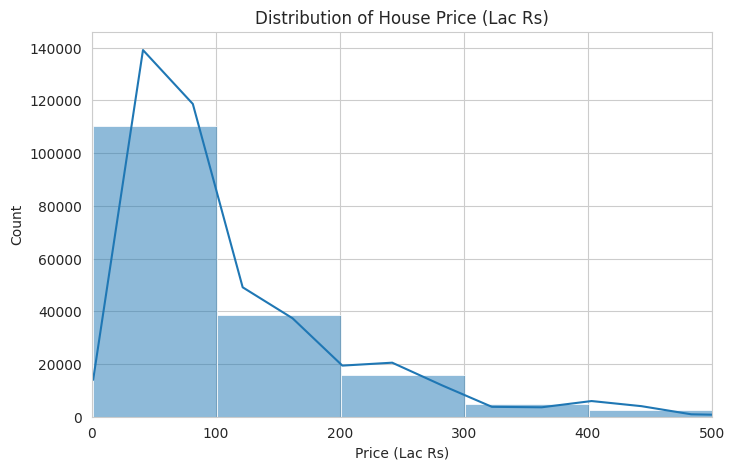

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_c['Price_Rs'] / 1e5, bins=80, kde=True)
plt.xlim(0, 500)
plt.xlabel('Price (Lac Rs)')
plt.title('Distribution of House Price (Lac Rs)')
plt.show()


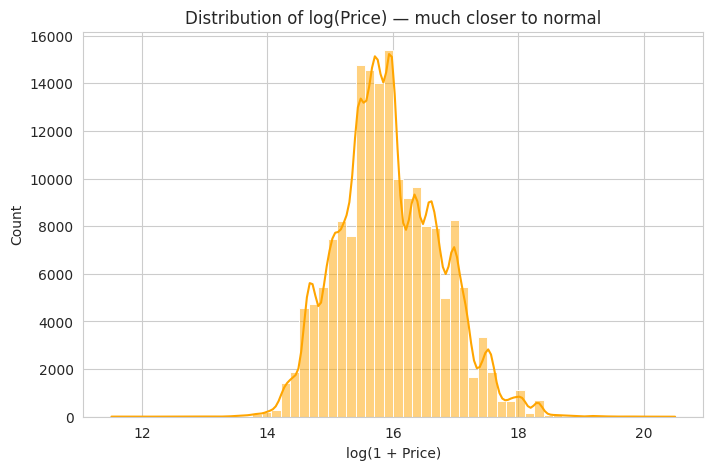

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_c['Price_Rs']), bins=60, kde=True, color='orange')
plt.xlabel('log(1 + Price)')
plt.title('Distribution of log(Price) — much closer to normal')
plt.show()


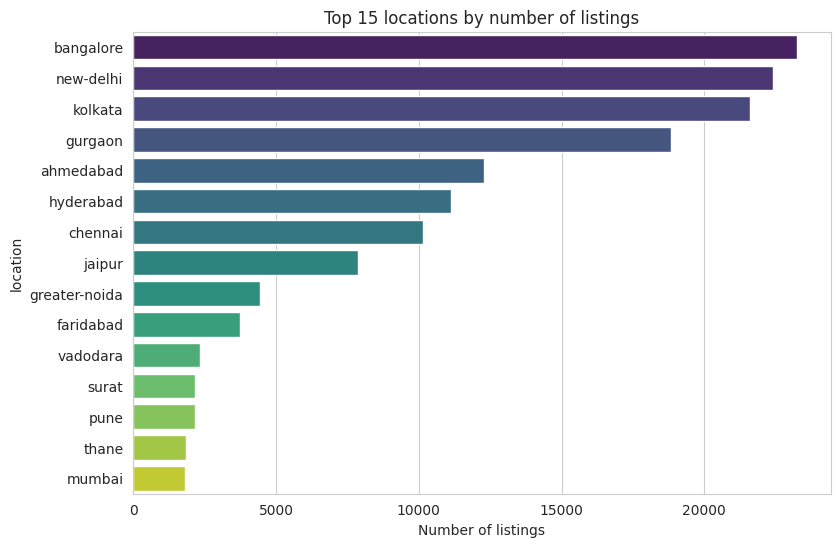

In [11]:
top_locations = df_c['location'].value_counts().head(15)
plt.figure(figsize=(9,6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.xlabel('Number of listings')
plt.title('Top 15 locations by number of listings')
plt.show()


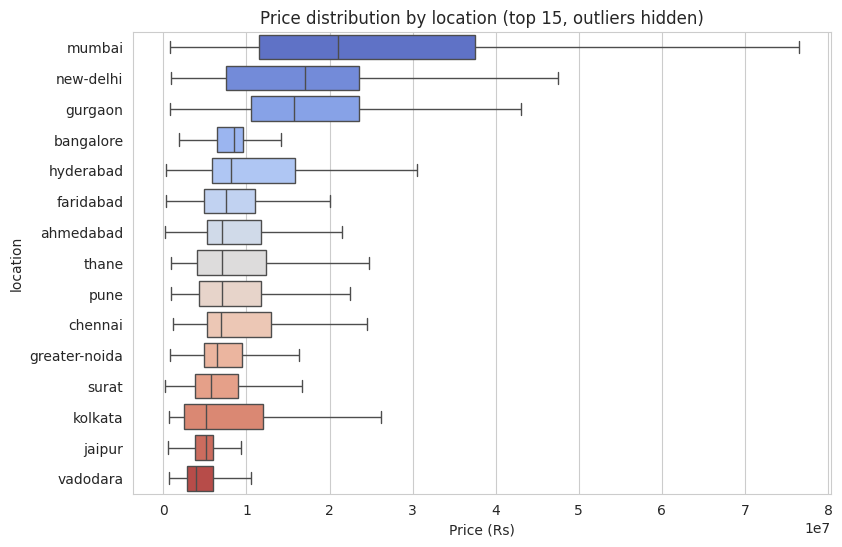

In [12]:
plt.figure(figsize=(9,6))
top15 = df_c[df_c['location'].isin(top_locations.index)]
order = top15.groupby('location')['Price_Rs'].median().sort_values(ascending=False).index
sns.boxplot(data=top15, x='Price_Rs', y='location', order=order, showfliers=False, palette='coolwarm')
plt.xlabel('Price (Rs)')
plt.title('Price distribution by location (top 15, outliers hidden)')
plt.show()


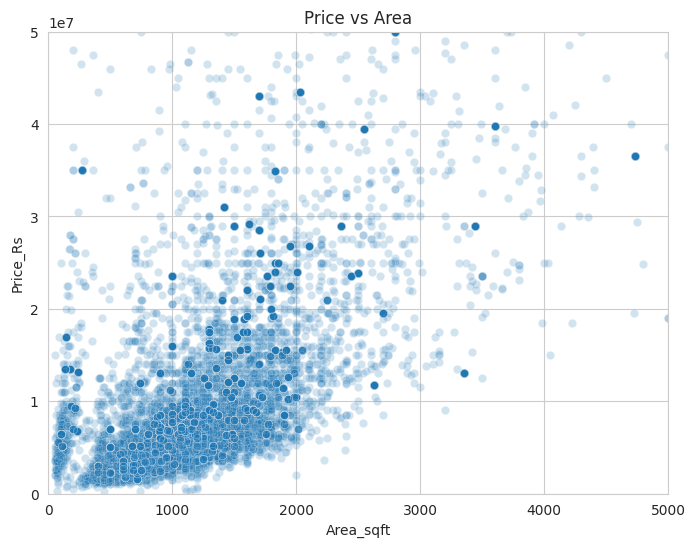

In [13]:
plt.figure(figsize=(8,6))
sample = df_c.sample(min(20000, len(df_c)), random_state=42)
sns.scatterplot(data=sample, x='Area_sqft', y='Price_Rs', alpha=0.2)
plt.xlim(0, 5000)
plt.ylim(0, 5e7)
plt.title('Price vs Area')
plt.show()


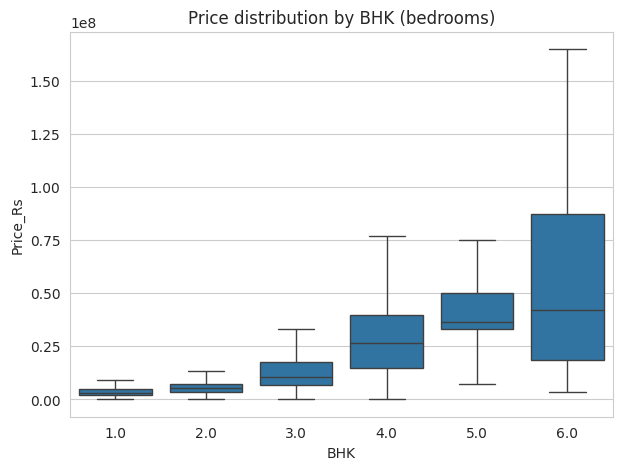

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_c[df_c['BHK'] <= 6], x='BHK', y='Price_Rs', showfliers=False)
plt.title('Price distribution by BHK (bedrooms)')
plt.show()


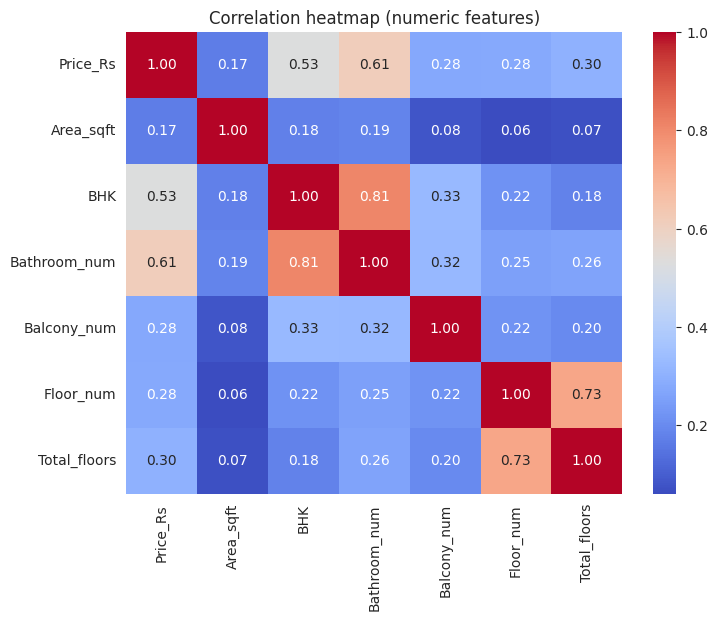

In [15]:
numeric_df = df_c[['Price_Rs', 'Area_sqft', 'BHK', 'Bathroom_num', 'Balcony_num', 'Floor_num', 'Total_floors']]
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap (numeric features)')
plt.show()


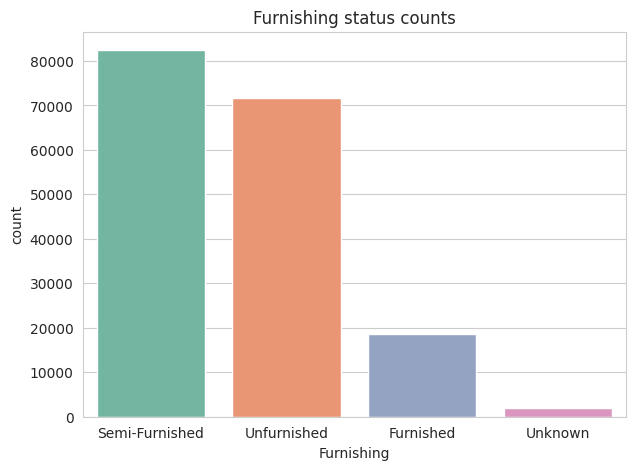

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_c, x='Furnishing', order=df_c['Furnishing'].value_counts().index, palette='Set2')
plt.title('Furnishing status counts')
plt.show()


## 4. Feature Engineering

We add a few derived features and prepare the data for modeling:
- `Price_per_sqft` — useful for EDA, not used as a model input (it would leak the target).
- `Floor_ratio` — floor number divided by total floors (captures relative position).
- Group rare locations into `'Other'` to keep the categorical cardinality manageable.
- A binary classification target `Price_Category` (Low / Medium / High) is created from price terciles, for the logistic regression / classification task.


In [17]:
df_fe = df_c.copy()

# Price per sqft (for analysis only, dropped before modeling)
df_fe['Price_per_sqft'] = df_fe['Price_Rs'] / df_fe['Area_sqft'].replace(0, np.nan)

# Relative floor position
df_fe['Floor_ratio'] = (df_fe['Floor_num'] / df_fe['Total_floors'].replace(0, np.nan)).fillna(0).clip(0, 1)

# Bucket rare locations as 'Other' (keep top 20)
top_locs = df_fe['location'].value_counts().head(20).index
df_fe['location_grouped'] = np.where(df_fe['location'].isin(top_locs), df_fe['location'], 'Other')

# Classification target: price tercile buckets
df_fe['Price_Category'] = pd.qcut(df_fe['Price_Rs'], q=3, labels=['Low', 'Medium', 'High'])

print(df_fe['Price_Category'].value_counts())
df_fe[['Price_Rs', 'Price_per_sqft', 'Floor_ratio', 'location_grouped', 'Price_Category']].head()


Price_Category
Low       58500
High      58249
Medium    58015
Name: count, dtype: int64


,Price_Rs,Price_per_sqft,Floor_ratio,location_grouped,Price_Category
0,4200000.0,8400.000000,0.909091,thane,Low
1,9800000.0,20718.816068,0.136364,thane,Medium
2,14000000.0,17971.758665,0.344828,thane,High
3,2500000.0,4716.981132,0.333333,thane,Low
4,16000000.0,25196.850394,0.476190,thane,High


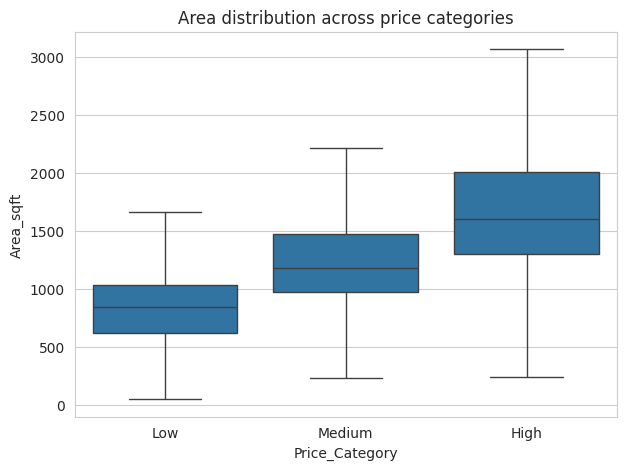

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_fe, x='Price_Category', y='Area_sqft', order=['Low','Medium','High'], showfliers=False)
plt.title('Area distribution across price categories')
plt.show()


## 5. Model 1 — Linear Regression (Predicting Price)

We predict the continuous target `Price_Rs` using numeric + categorical features. Numeric features are standardized, categorical features are one-hot encoded, all within a single `Pipeline` to avoid data leakage.

In [19]:
feature_cols_num = ['Area_sqft', 'BHK', 'Bathroom_num', 'Balcony_num', 'Floor_ratio']
feature_cols_cat = ['location_grouped', 'Transaction', 'Furnishing', 'Status', 'Ownership', 'facing']

X = df_fe[feature_cols_num + feature_cols_cat]
y = df_fe['Price_Rs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_cat)
])

lr_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : Rs {mae:,.0f}")
print(f"RMSE : Rs {rmse:,.0f}")
print(f"R^2  : {r2:.3f}")


MAE  : Rs 5,378,815
RMSE : Rs 9,639,390
R^2  : 0.489


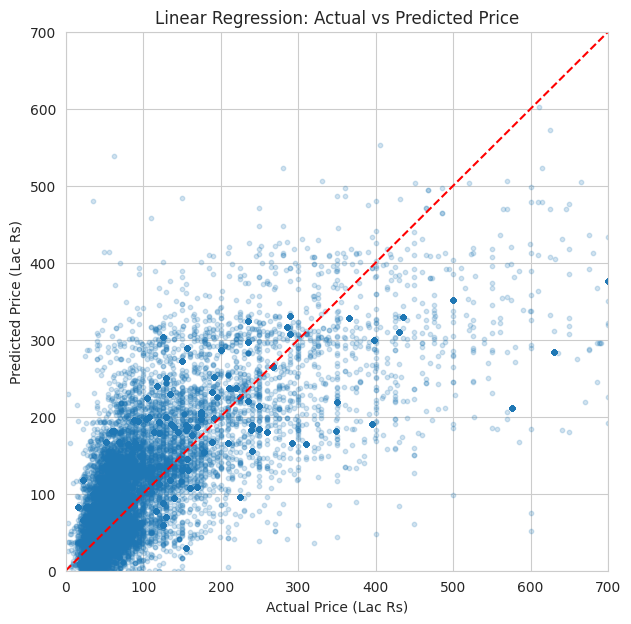

In [20]:
plt.figure(figsize=(7,7))
plt.scatter(y_test/1e5, y_pred/1e5, alpha=0.2, s=10)
lims = [0, np.percentile(y_test, 99)/1e5]
plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Actual Price (Lac Rs)')
plt.ylabel('Predicted Price (Lac Rs)')
plt.title('Linear Regression: Actual vs Predicted Price')
plt.show()


In [21]:
# Try a log-transformed target, often improves regression on skewed prices
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

lr_log_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
lr_log_pipeline.fit(X_train, y_train_log)
y_pred_log = lr_log_pipeline.predict(X_test)

# Back-transform to rupee scale for fair comparison
y_test_rs = np.expm1(y_test_log)
y_pred_rs = np.expm1(y_pred_log)

mae_log = mean_absolute_error(y_test_rs, y_pred_rs)
rmse_log = np.sqrt(mean_squared_error(y_test_rs, y_pred_rs))
r2_log = r2_score(y_test_rs, y_pred_rs)

print("Log-target Linear Regression (back-transformed to Rs):")
print(f"MAE  : Rs {mae_log:,.0f}")
print(f"RMSE : Rs {rmse_log:,.0f}")
print(f"R^2  : {r2_log:.3f}")


Log-target Linear Regression (back-transformed to Rs):
MAE  : Rs 5,394,176
RMSE : Rs 78,730,094
R^2  : -33.087


In [22]:
print(f"{'Model':<30}{'MAE (Rs)':>15}{'RMSE (Rs)':>18}{'R2':>8}")
print(f"{'Linear Regression':<30}{mae:>15,.0f}{rmse:>18,.0f}{r2:>8.3f}")
print(f"{'Linear Regression (log target)':<30}{mae_log:>15,.0f}{rmse_log:>18,.0f}{r2_log:>8.3f}")


Model                                MAE (Rs)         RMSE (Rs)      R2
Linear Regression                   5,378,815         9,639,390   0.489
Linear Regression (log target)      5,394,176        78,730,094 -33.087


## 6. Model 2 — Classification with Logistic Regression (Price Category)

We now treat the problem as classification: predict whether a property is `Low`, `Medium`, or `High` priced (terciles of `Price_Rs`) using the same feature set (excluding price-derived columns).

In [23]:
X_cls = df_fe[feature_cols_num + feature_cols_cat]
y_cls = df_fe['Price_Category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c = clf_pipeline.predict(X_test_c)

acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_test_c, y_pred_c))


Accuracy: 0.751



              precision    recall  f1-score   support

        High       0.79      0.80      0.80     11650
         Low       0.77      0.83      0.80     11700
      Medium       0.69      0.62      0.65     11603

    accuracy                           0.75     34953
   macro avg       0.75      0.75      0.75     34953
weighted avg       0.75      0.75      0.75     34953



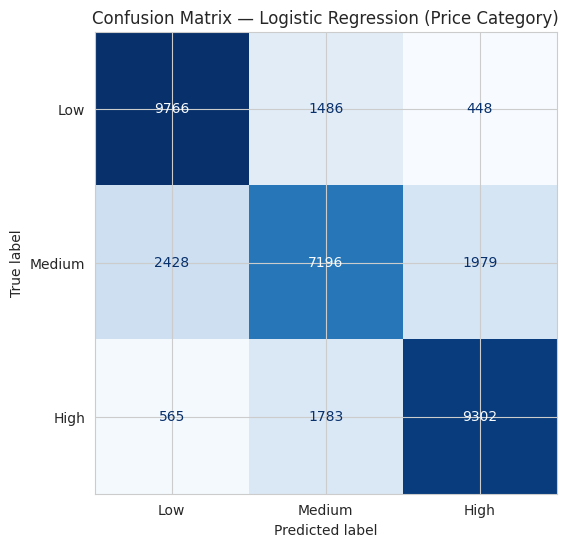

In [24]:
cm = confusion_matrix(y_test_c, y_pred_c, labels=['Low','Medium','High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','Medium','High'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression (Price Category)')
plt.show()


In [25]:
# Binary classification variant: is the property 'High' priced or not?
y_binary = (df_fe['Price_Category'] == 'High').astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_cls, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

bin_clf = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])
bin_clf.fit(X_train_b, y_train_b)
y_pred_b = bin_clf.predict(X_test_b)
y_proba_b = bin_clf.predict_proba(X_test_b)[:, 1]

print(f"Binary accuracy (High vs Not-High): {accuracy_score(y_test_b, y_pred_b):.3f}\n")
print(classification_report(y_test_b, y_pred_b, target_names=['Not High', 'High']))


Binary accuracy (High vs Not-High): 0.862

              precision    recall  f1-score   support

    Not High       0.88      0.92      0.90     23303
        High       0.82      0.75      0.78     11650

    accuracy                           0.86     34953
   macro avg       0.85      0.84      0.84     34953
weighted avg       0.86      0.86      0.86     34953



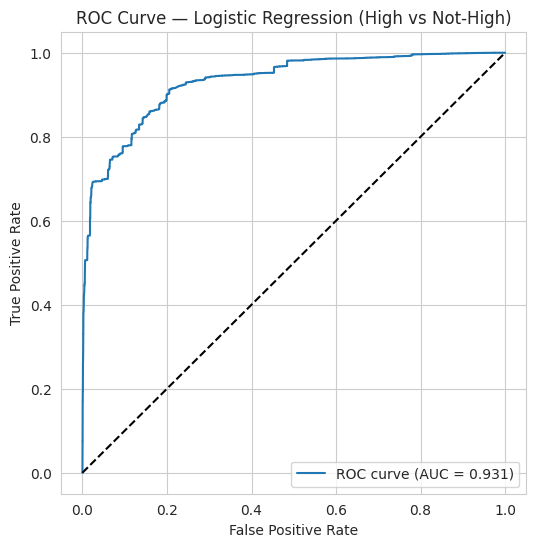

In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test_b, y_proba_b)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (High vs Not-High)')
plt.legend()
plt.show()


## 7. Feature Importance (Linear Regression Coefficients)

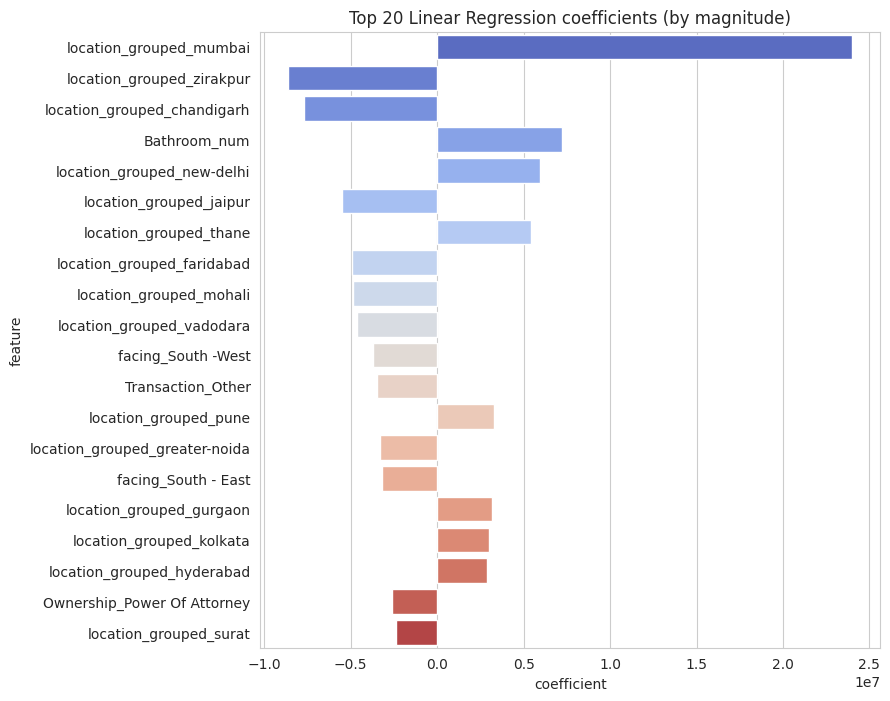

In [27]:
ohe_feature_names = lr_pipeline.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(feature_cols_cat)
all_feature_names = feature_cols_num + list(ohe_feature_names)
coefs = lr_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(8,8))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.title('Top 20 Linear Regression coefficients (by magnitude)')
plt.show()


## 8. Summary & Conclusions

- **Data cleaning**: Parsed messy text fields (`Amount(in rupees)`, `Carpet Area`, `Floor`, `Title`) into clean numeric columns; removed unrealistic outliers (extremely small areas, extreme prices).
- **EDA**: Price is heavily right-skewed (a log transform helps); `Area_sqft` and `BHK` are the strongest visible drivers of price; price varies a lot by `location`.
- **Feature engineering**: Derived `Floor_ratio`, grouped rare locations into `Other`, and created a 3-class `Price_Category` target for classification.
- **Linear Regression**: Predicts the continuous price; using a log-transformed target improved fit (compare R², MAE, RMSE printed above).
- **Logistic Regression**: Both a 3-class (Low/Medium/High) and a binary (High vs Not-High) classifier were trained; accuracy and ROC-AUC are reported above.

### Possible next steps
- Try non-linear models (Random Forest, Gradient Boosting) for stronger performance.
- Use `Society` and `Description` text features (e.g. TF-IDF) for richer signal.
- Tune hyperparameters and use cross-validation instead of a single train/test split.
